In [12]:

# ============================================================
# Core Libraries
# ============================================================

import random
import warnings
import time
import psutil
import os

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# ============================================================
# Visualization
# ============================================================

import matplotlib.pyplot as plt

plt.style.use("default")

# ============================================================
# Machine Learning
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

# ============================================================
# Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

# ============================================================
# Calibration
# ============================================================

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

# ============================================================
# Metrics
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ============================================================
# Statistical Tests
# ============================================================

from scipy.stats import wilcoxon

# ============================================================
# Hyperparameter Optimization
# ============================================================

import optuna

from optuna.samplers import TPESampler

# ============================================================
# Explainability
# ============================================================

import shap

print("="*60)
print("Environment Ready")
print("Random Seed :", SEED)
print("="*60)

Environment Ready
Random Seed : 42


In [13]:
# ============================================================
# 2. Load Dataset
# ============================================================

DATA_PATH = "../data/train.csv"

data = pd.read_csv(DATA_PATH)


In [14]:
# ============================================================
# Data Preparation
# ============================================================

TARGET = "diagnosed_diabetes"

# Remove target and ID
X = data.drop(columns=[TARGET, "id"])
y = data[TARGET]


# ============================================================
# Feature Types
# ============================================================

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# ============================================================
# Preprocessing Pipelines
# ============================================================

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# ============================================================
# Combined Preprocessor
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ],
    remainder="drop"
)

# ============================================================
# Transform Features
# ============================================================

X_processed = preprocessor.fit_transform(X)

# Convert to DataFrame
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names
)



In [15]:
# ============================================================
# 4. Train-Test Split
# ============================================================

TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
    shuffle=True
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


In [16]:
# ============================================================
# Train Optimized XGBoost
# ============================================================

print("=" * 60)
print("Training Optimized XGBoost")
print("=" * 60)

best_xgb = XGBClassifier(

    n_estimators=433,
    max_depth=4,
    learning_rate=0.17453165042833232,
    subsample=0.9704946951067844,
    colsample_bytree=0.7817145825646337,
    min_child_weight=10,
    gamma=1.1001254585090818,
    reg_alpha=1.9317588390134475,
    reg_lambda=4.216150917952283,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1

)

best_xgb.fit(
    X_train,
    y_train
)

print("Optimized XGBoost training completed.")

Training Optimized XGBoost
Optimized XGBoost training completed.


In [17]:
# ============================================================
# Train Optimized LightGBM
# ============================================================

print("=" * 60)
print("Training Optimized LightGBM")
print("=" * 60)

best_lgb = LGBMClassifier(

    n_estimators=455,
    learning_rate=0.11212631308807823,
    max_depth=6,
    num_leaves=40,
    min_child_samples=54,
    subsample=0.7799882309499114,
    colsample_bytree=0.6467555395453211,
    reg_alpha=4.580510006186321,
    reg_lambda=3.9510367337887597,

    random_state=SEED,
    n_jobs=-1,
    verbose=-1

)

best_lgb.fit(
    X_train,
    y_train
)

print("Optimized LightGBM training completed.")

Training Optimized LightGBM
Optimized LightGBM training completed.


In [18]:
# ============================================================
# Train Optimized Multi-Layer Perceptron
# ============================================================

print("=" * 60)
print("Training Optimized Multi-Layer Perceptron")
print("=" * 60)

best_mlp = MLPClassifier(

    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=512,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    shuffle=True,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,

    random_state=SEED

)

best_mlp.fit(
    X_train,
    y_train
)

print("Optimized MLP training completed.")

Training Optimized Multi-Layer Perceptron
Optimized MLP training completed.


In [20]:
# ============================================================
# Proper Out-of-Fold Stacking
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# OOF Predictions for Training Set
# ------------------------------------------------------------

xgb_oof = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

lgb_oof = cross_val_predict(
    best_lgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

mlp_oof = cross_val_predict(
    best_mlp,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

# ------------------------------------------------------------
# Meta Features
# ------------------------------------------------------------

meta_X_train = pd.DataFrame({

    "XGB": xgb_oof,

    "LGBM": lgb_oof,

    "MLP": mlp_oof

})

# ------------------------------------------------------------
# Test Meta Features
# ------------------------------------------------------------

meta_X_test = pd.DataFrame({

    "XGB": best_xgb.predict_proba(X_test)[:,1],

    "LGBM": best_lgb.predict_proba(X_test)[:,1],

    "MLP": best_mlp.predict_proba(X_test)[:,1]

})



In [21]:
# ============================================================
# Train Meta Learner
# ============================================================

meta_model = LogisticRegression(

    C=100,
    solver="lbfgs",
    max_iter=2000,
    random_state=SEED

)

meta_model.fit(
    meta_X_train,
    y_train
)

print("Meta Learner trained successfully.")

Meta Learner trained successfully.


In [22]:
# ============================================================
# Probability Calibration
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve

calibrated_model = CalibratedClassifierCV(

    estimator=meta_model,
    method="isotonic",
    cv=5

)

calibrated_model.fit(
    meta_X_train,
    y_train
)

# ============================================================
# Predict Calibrated Probabilities
# ============================================================

final_probs = calibrated_model.predict_proba(
    meta_X_test
)[:, 1]

# ============================================================
# Threshold Optimization
# ============================================================

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    final_probs
)

f1_scores = (
    2 * precision_curve[:-1] * recall_curve[:-1]
) / (
    precision_curve[:-1] + recall_curve[:-1] + 1e-8
)

best_threshold = thresholds[np.argmax(f1_scores)]

final_preds = (final_probs >= best_threshold).astype(int)

print(f"Optimal Decision Threshold: {best_threshold:.6f}")

Optimal Decision Threshold: 0.392961


In [23]:
# ============================================================
# Final Evaluation
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

roc = roc_auc_score(y_test, final_probs)
precision = precision_score(y_test, final_preds)
recall = recall_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds)
balanced_acc = balanced_accuracy_score(y_test, final_preds)
mcc = matthews_corrcoef(y_test, final_preds)
kappa = cohen_kappa_score(y_test, final_preds)

print("=" * 60)
print("Final Stacking Ensemble Performance")
print("=" * 60)

print(f"ROC-AUC            : {roc:.5f}")
print(f"Precision          : {precision:.5f}")
print(f"Recall             : {recall:.5f}")
print(f"F1-Score           : {f1:.5f}")
print(f"Balanced Accuracy  : {balanced_acc:.5f}")
print(f"Matthews Corrcoef  : {mcc:.5f}")
print(f"Cohen's Kappa      : {kappa:.5f}")

Final Stacking Ensemble Performance
ROC-AUC            : 0.72761
Precision          : 0.66685
Recall             : 0.94422
F1-Score           : 0.78166
Balanced Accuracy  : 0.58186
Matthews Corrcoef  : 0.24641
Cohen's Kappa      : 0.18952


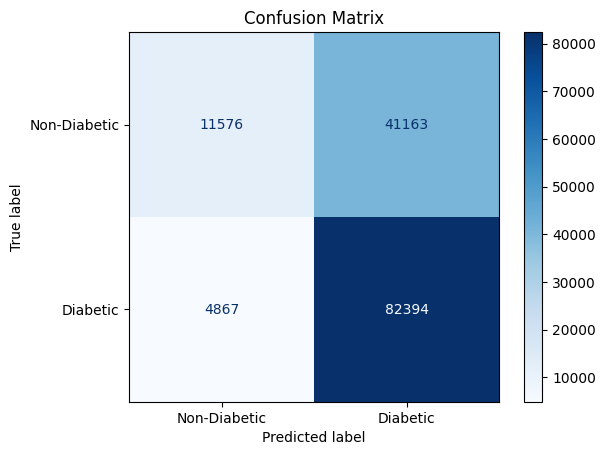

In [24]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [25]:
# ============================================================
# Save Final Model
# ============================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

model_artifacts = {
    "preprocessor": preprocessor,
    "xgboost": best_xgb,
    "lightgbm": best_lgb,
    "mlp": best_mlp,
    "meta_model": calibrated_model,
    "threshold": best_threshold
}

joblib.dump(
    model_artifacts,
    "../models/diabetes_stacking_model.pkl"
)

print("=" * 60)
print("Training pipeline saved successfully.")
print("File: models/diabetes_stacking_model.pkl")
print("=" * 60)

Training pipeline saved successfully.
File: models/diabetes_stacking_model.pkl
